In [1]:
from src.Elements import Elements
# from src.models.XRFAutoencoder import XRFAutoencoder
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from src.models import VisionTransformer

PATH = Path("data/model_weights/VisionTransformer--2025-04-11--22-55-43")
input_size = 4096
patch_size = 16
embed_dim = 16 
num_heads = 4
num_classes = len(Elements.LINES) 
num_layers = 6
hidden_dim = 4 * embed_dim
dropout_rate = 0.1

model = VisionTransformer(input_size, patch_size, embed_dim, num_heads, num_classes, num_layers, hidden_dim, dropout_rate).to(device)
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graph = draw_graph(model, input_size=(64, 1, 4096))
graphviz.set_jupyter_format('png')


torch.Size([16])
89616


'svg'

In [6]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/semi_artifficial_test/X.npy")
y = np.load("data/semi_artifficial_test/y.npy")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 128)


In [ ]:
import matplotlib.pyplot as plt

for i, (X_batch, y_batch) in enumerate(testloader):
    X_true, y_true = X_batch.cpu().squeeze().detach().numpy()[0], y_batch.cpu().squeeze().detach().numpy()[0]
    X_pred, y_pred = model(X_batch)[0].cpu().squeeze().detach().numpy()[0], model(X_batch)[1].cpu().squeeze().detach().numpy()[0]
    print(X_true.shape)

    true_label = ", ".join([f"{Elements.NUM2SYMBOL[i]}: {v:.2f}" for i, v in enumerate(y_true)])
    pred_label = ", ".join([f"{Elements.NUM2SYMBOL[i]}: {v:.2f}" for i, v in enumerate(y_pred)])
    plt.figure(i)
    plt.plot(X_true, label=true_label)
    plt.plot(X_pred, label=pred_label)
    plt.legend()
    if i == 10:
        break

(4096,)


TypeError: 'numpy.float32' object is not iterable

In [ ]:
X_pred, Y_pred, Z_pred = [], [], []
X_true, Z_true = [], [] 
for j, (X_batch, y_batch) in enumerate(testloader):
    output = model(X_batch)
    print(output[0].shape)
    X_pred.append(output[0].detach().cpu().numpy().reshape(-1, 4096))
    Y_pred.append(output[1].detach().cpu().numpy().reshape(-1, 7))
    Z_pred.append(output[2].detach().cpu().numpy().reshape(-1, 7))

    X_true.append(X_batch.detach().cpu().numpy().reshape(-1, 4096))
    Z_true.append(y_batch.detach().cpu().numpy().reshape(-1, 7))

torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
torch.Size([128, 1, 4096])
t

In [ ]:
X_pred = np.concatenate(X_pred).reshape(-1, 4096)
Y_pred = np.concatenate(Y_pred).reshape(-1, 7)
Z_pred = np.concatenate(Z_pred).reshape(-1, 7)

X_true = np.concatenate(X_true).reshape(-1, 4096)
Z_true = np.concatenate(Z_true).reshape(-1, 7)

In [ ]:
print(X_pred.shape)
print(Y_pred.shape)
print(Z_pred.shape)
print(X_true.shape)
print(Z_true.shape)

(10000, 4096)
(10000, 7)
(10000, 7)
(10000, 4096)
(10000, 7)


In [ ]:
print(Z_pred)

[[6.7559940e-01 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 3.2408875e-01]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 1.0000000e+00]
 [0.0000000e+00 0.0000000e+00 5.6223187e-04 ... 0.0000000e+00
  1.1957502e-03 9.9824202e-01]
 ...
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  1.0000000e+00 0.0000000e+00]
 [0.0000000e+00 5.6734994e-02 0.0000000e+00 ... 0.0000000e+00
  9.4326496e-01 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 1.0000000e+00
  0.0000000e+00 0.0000000e+00]]


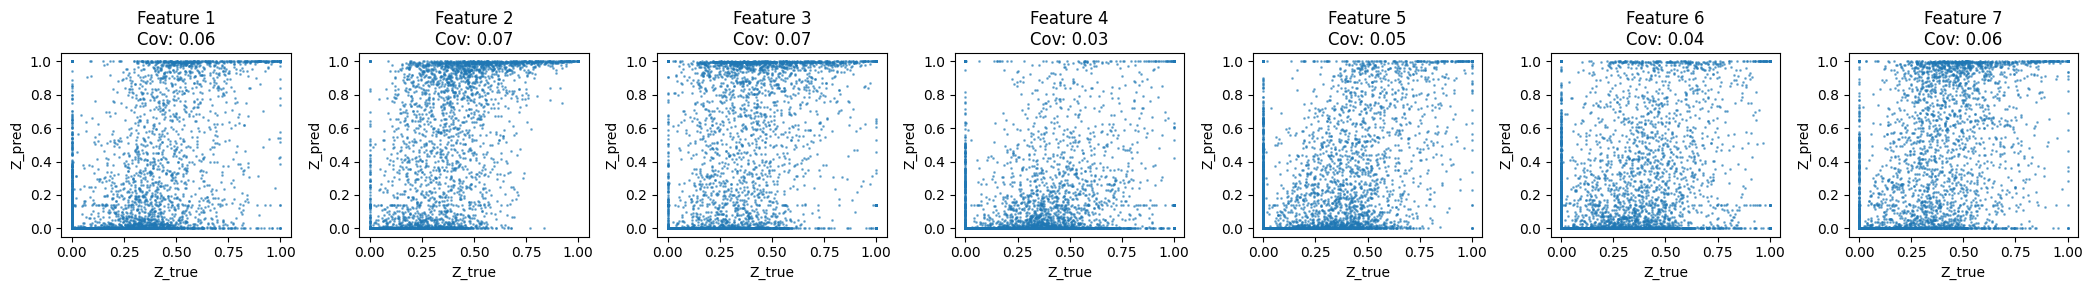

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(1, 7, figsize=(21, 3))

for i in range(7):
    cov_value = np.cov(Z_true[:, i], Z_pred[:, i])[0, 1]
    
    axes[i].scatter(Z_true[:, i], Z_pred[:, i], alpha=0.5, s=1)
    axes[i].set_title(f"Feature {i+1}\nCov: {cov_value:.2f}")
    axes[i].set_xlabel("Z_true")
    axes[i].set_ylabel("Z_pred")

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import numpy as np
npz = np.load(Path("data/Sobieski/Sobieski_data_corr_total.npz"), allow_pickle=True)
sobieski_e_xy = npz["E_xy"]

In [ ]:
from skimage.filters import gaussian
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from scipy.ndimage import convolve
import matplotlib.pyplot as plt 
from skimage.measure import block_reduce


peaks_sobieski = [817, 1016,1347, 1598]
energies_sobieski =[6.405, 8.046, 10.551, 12.614] 

kernel_size = 1 

sobieski_averaged = block_reduce(sobieski_e_xy, block_size=(kernel_size, kernel_size, 1), func=np.mean)

print(sobieski_averaged.shape)

energy_range, spectra = DataPreprocessor.processed_spectra(sobieski_averaged, peaks_sobieski, energies_sobieski)
print(spectra.shape)

(524, 348, 4094)
(524, 348, 4096)


In [ ]:
import matplotlib.pyplot as plt

def increase_contrast(image, factor=1.5):
    """
    Increases the contrast of a single-channel image.
    
    Parameters:
        image (numpy.ndarray): Input image with values in range [0, 1].
        factor (float): Contrast adjustment factor. Greater than 1 increases contrast.
    
    Returns:
        numpy.ndarray: Contrast-enhanced image, clipped to [0, 1].
    """
    mean = np.mean(image)  # Compute mean intensity
    contrasted = (image - mean) * factor + mean  # Apply contrast adjustment
    return np.clip(contrasted, 0, 1)  # Ensure values remain in [0, 1]

def downsample_average(image, factor=32):
    """
    Downsamples a single-channel image by a given factor using block averaging.

    Parameters:
        image (numpy.ndarray): Input image (H, W) with values in range [0, 1].
        factor (int): Downsampling factor.

    Returns:
        numpy.ndarray: Downsampled image.
    """
    H, W = image.shape
    H_new, W_new = H // factor, W // factor  # New size
    return image[:H_new * factor, :W_new * factor].reshape(H_new, factor, W_new, factor).max(axis=(1, 3))


print(X_train[0])
plt.plot(X_train[0])

plt.figure(10)
plt.imshow(downsample_average(increase_contrast(torch.tensor(spectra[0]).reshape(-1, 1).matmul(torch.tensor(spectra[50][50]).reshape(1, -1)).detach().cpu().numpy(), 1)), vmin=0, vmax=1, cmap="jet")
plt.xticks(np.arange(0, 128, 4))
plt.yticks(np.arange(0, 128, 4))
plt.grid(which='both', color="yellow", linestyle='-', linewidth=1)

In [ ]:
H, W, C = spectra.shape
batch_size_total = H * W
input_tensor = torch.tensor(spectra, dtype=torch.float).view(batch_size_total, C).to(device).unsqueeze(1)

batch_size = 128

outputs = []
for i in range(0, batch_size_total, batch_size):
    batch = input_tensor[i:i + batch_size]
    output = model(batch)
    outputs.append([o.detach().cpu() for o in output])

# final_output = torch.cat(outputs, dim=0).reshape((H, W, C))

# print("Output shape:", final_output.shape) 

In [ ]:
X = torch.cat([outputs[i][0].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))
Y = torch.cat([outputs[i][1].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))
Z = torch.cat([outputs[i][2].squeeze(1) for i in range(len(outputs))]).reshape((*spectra.shape[:-1], -1))

In [ ]:
print(X.shape)
print(Y.shape)
print(Z.shape)

torch.Size([524, 348, 4096])
torch.Size([524, 348, 7])
torch.Size([524, 348, 7])


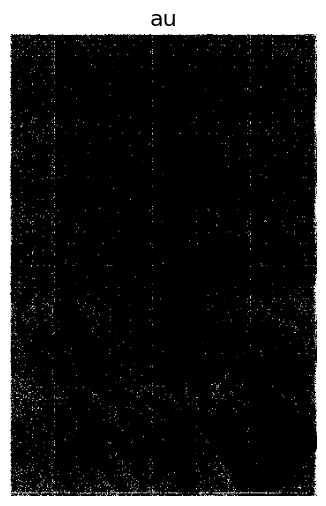

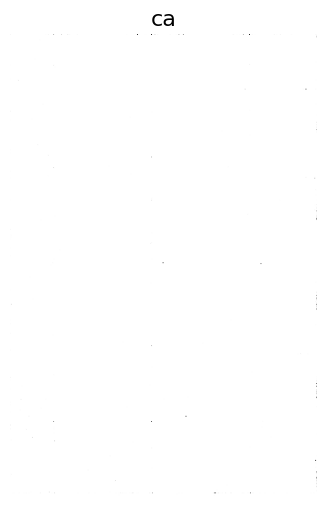

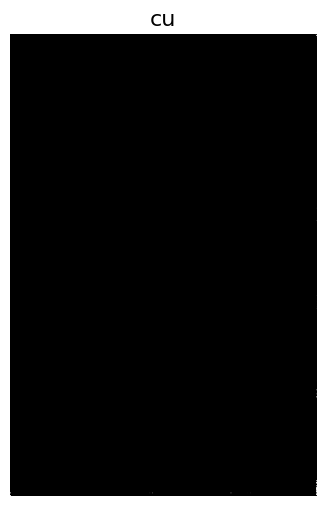

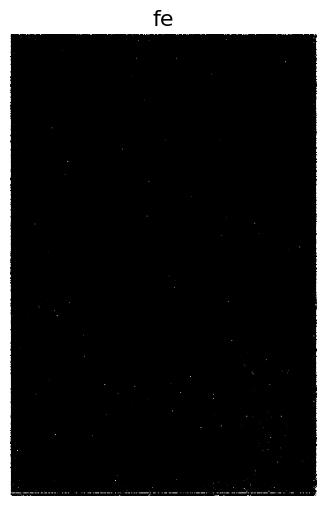

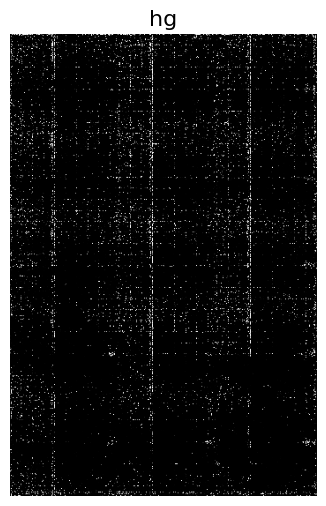

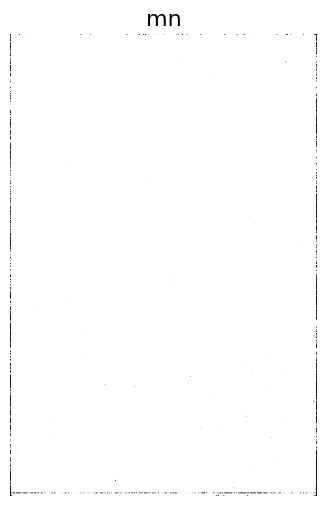

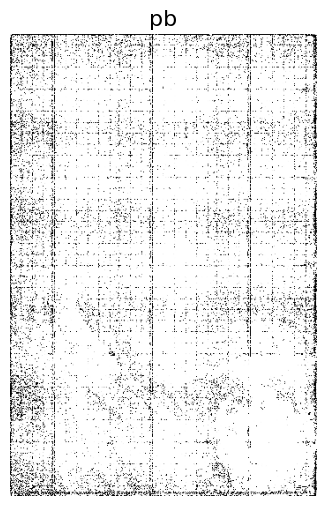

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

tensor = Y.cpu().detach().numpy()
cmap = plt.cm.grey

# Mask values < 1e-3 and set them to black
mask = tensor < 1e-3
tensor_rgba = cmap(tensor)  # Convert tensor to RGBA
tensor_rgba[mask] = [0, 0, 0, 1]  # Assign black to masked regions

# Define colorbar separately
fig, ax = plt.subplots(figsize=(1, 6))
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap), cax=ax)
cbar.ax.set_title("Color Scale", fontsize=12)
fig.savefig("colorbar.png", bbox_inches="tight")  # Save colorbar separately
plt.close(fig)

# Save each slice as an individual image
for i in range(7):  # Assuming 7 images
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(tensor_rgba[:, :, i])  # Use RGBA image
    ax.axis("off")
    ax.set_title(f"{Elements.NUM2SYMBOL[i]}", fontsize=16)
    


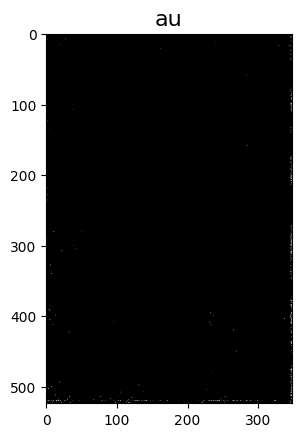

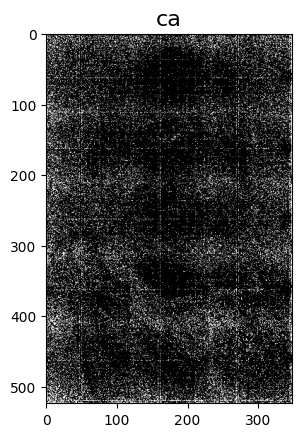

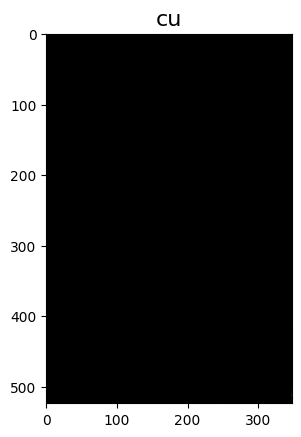

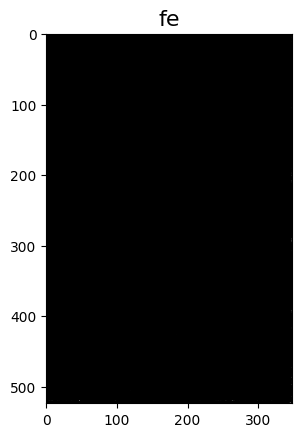

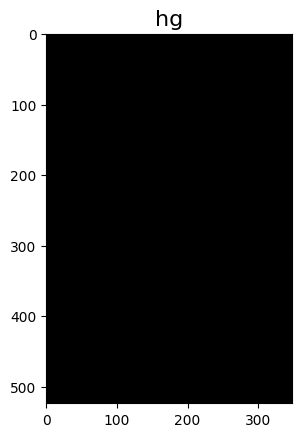

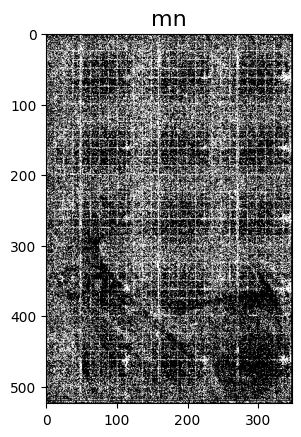

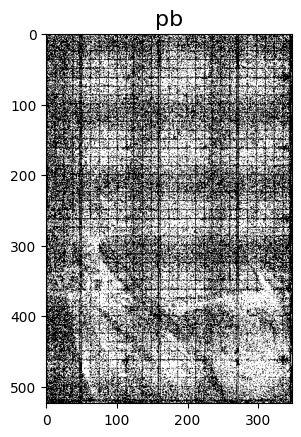

In [ ]:

tensor = Z.cpu().detach()

# Define the colormap and set values < 1e-3 to black
cmap = plt.cm.gray

# Set values < 1e-3 to black
tensor_np = tensor.numpy()
mask = tensor_np < 1e-3
tensor_np_rgba = cmap(tensor_np)  # Get RGBA values
tensor_np_rgba[mask] = [0, 0, 0, 1]  # Assign black to masked regions


for i in range(7):
    plt.figure(i)
    plt.imshow(tensor_np_rgba[:, :, i])  # Display single image
    plt.title(f"{Elements.NUM2SYMBOL[i]}", fontsize=16)  # Set title
    

In [ ]:
print(Z)

tensor([[[9.9993e-01, 2.6648e-11, 0.0000e+00,  ..., 0.0000e+00,
          8.4637e-14, 7.1118e-05],
         [9.9975e-01, 2.2251e-08, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 2.4587e-04],
         [1.6511e-04, 5.3966e-15, 0.0000e+00,  ..., 0.0000e+00,
          2.4201e-08, 9.9983e-01],
         ...,
         [1.4352e-05, 3.0163e-06, 0.0000e+00,  ..., 0.0000e+00,
          1.6151e-13, 9.9998e-01],
         [1.8348e-03, 1.2513e-06, 0.0000e+00,  ..., 0.0000e+00,
          1.8912e-04, 9.9797e-01],
         [0.0000e+00, 9.7870e-01, 0.0000e+00,  ..., 0.0000e+00,
          4.6890e-06, 2.1285e-02]],

        [[7.5752e-01, 3.1301e-14, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 2.4248e-01],
         [0.0000e+00, 1.5593e-17, 0.0000e+00,  ..., 0.0000e+00,
          9.9999e-01, 8.3419e-06],
         [0.0000e+00, 3.6745e-15, 0.0000e+00,  ..., 0.0000e+00,
          5.5692e-03, 9.9443e-01],
         ...,
         [0.0000e+00, 8.0937e-18, 0.0000e+00,  ..., 0.0000e+00,
          7.306